In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 0. import
from pathlib import Path
import os
import json
import random
import math
from typing import List, Dict, Any, Tuple, Optional

import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# 1. 경로 설정
BASE_DIR = Path("/content/drive/MyDrive/먼작귀")

BACKGROUND_PATH = BASE_DIR / "창고 이미지" / "선반이미지_사이드.png"

BG_REMOVED_DIR = BASE_DIR / "dataset" / "bg_removed"

CAN_FG_DIR = BG_REMOVED_DIR / "통조림_안주"
ROOM_FG_DIR = BG_REMOVED_DIR / "상온"
ETC_FG_DIR = BG_REMOVED_DIR / "기타"

OUTPUT_DIR = BASE_DIR / "synthetic_side"
OUTPUT_IMAGE_DIR = OUTPUT_DIR / "images"
OUTPUT_JSON_DIR = OUTPUT_DIR / "labels_json"
OUTPUT_YOLO_DIR = OUTPUT_DIR / "labels_yolo"
OUTPUT_COORD_DIR = OUTPUT_DIR / "coords"

for d in [OUTPUT_IMAGE_DIR, OUTPUT_JSON_DIR, OUTPUT_YOLO_DIR, OUTPUT_COORD_DIR]:
    d.mkdir(parents=True, exist_ok=True)

COORDS_PATH = OUTPUT_COORD_DIR / "side_shelf_lips_slots_coords.json"

print("BACKGROUND_PATH:", BACKGROUND_PATH)
print("CAN_FG_DIR:", CAN_FG_DIR)
print("ROOM_FG_DIR:", ROOM_FG_DIR)
print("ETC_FG_DIR:", ETC_FG_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BACKGROUND_PATH: /content/drive/MyDrive/먼작귀/창고 이미지/선반이미지_사이드.png
CAN_FG_DIR: /content/drive/MyDrive/먼작귀/dataset/bg_removed/통조림_안주
ROOM_FG_DIR: /content/drive/MyDrive/먼작귀/dataset/bg_removed/상온
ETC_FG_DIR: /content/drive/MyDrive/먼작귀/dataset/bg_removed/기타
OUTPUT_DIR: /content/drive/MyDrive/먼작귀/synthetic_side


In [ ]:
# ============================================================
# 2. 기본 설정
# ============================================================

CATEGORY_ORDER = ["통조림_안주", "상온", "기타"]

CATEGORY_DIR_MAP = {
    "통조림_안주": CAN_FG_DIR,
    "상온": ROOM_FG_DIR,
    "기타": ETC_FG_DIR,
}

PRODUCTS_PER_CATEGORY = 4
SLOT_ROW_COUNT = 4
SLOTS_PER_CATEGORY_BY_ROW = [1, 1, 1, 1]

# ============================================================
# PNG 선택 설정
# ============================================================

ROW_IMAGE_KEYWORD = {
    "row_1": "30_s_24",
    "row_2": "30_s_24",
    "row_3": "30_s_24",
    "row_4": "30_s_24",
}

ONLY_USE_S_VIEW = True
S_VIEW_KEYWORD = "_s_"
M_VIEW_KEYWORD = "_m_"

DEBUG_SELECTED_PNG = True
FIXED_PNG_SELECTION = True

FORCE_PNG_KEYWORD_BY_PRODUCT_ID = {
    "50138": "60_s_24",  # 오뚜기3분쇠고기짜장200G
    "10169": "30_s_23",  # 롯데런천미트340G
    "66138": "30_s_23",  # 씨제이제일제당)비비고소고기죽
    "35963": "30_s_22",  # 머거본)콘소메맛아몬드
    "25425": "30_s_21"   # 오뚜기컵밥불닭마요덮밥277g
}

FORCE_PNG_FILENAME_BY_PRODUCT_ID = {}

# ============================================================
# 카테고리별 허용/제외 상품
# ============================================================

ALLOWED_PRODUCT_IDS_BY_CATEGORY = {
    "통조림_안주": {
        "10160",   # 골드)황도슬라이스
        "10169",   # 롯데런천미트340G
        "10170",   # CJ스팸200G
        "15037",   # 오뚜기스위트콘340G
        "35807",   # 한진식품)한입사각어포
        "35828",   # 한진식품)꼬마꾸이킹
        "35872",   # 세신식품)칼몬드
        "35882",   # 명성식품)한입부산어포
        "35963",   # 머거본)콘소메맛아몬드
        "40310",   # 프레스코후르츠칵테일410G
        "45026",   # 델몬트후레쉬컷슬라이스파인애플836G
        "50079",   # CJ렛츠웰맛밤80G
        "90147",   # 목우촌육포
        "A20022",  # 동원고추참치
    },
    "상온": {
        "10240",   # CJ햇반컵반설렁탕밥253g
        "10241",   # 오뚜기전복죽285g
        "15088",   # CJ비비고스팸부대찌개460G
        "15647",   # CJ맥스봉돼지숯불맛400G
        "25425",   # 오뚜기컵밥불닭마요덮밥277g
        "35763",   # 길림양행)구운아몬드
        "50135",   # 오뚜기3분카레약간매운맛200G
        "50138",   # 오뚜기3분쇠고기짜장200G
        "66135",   # 태광푸드)볶은통귀리
        "66138",   # 씨제이제일제당)비비고소고기죽
        "66245",   # 미소)초이스엘참치닭가슴살5개입
        "70205",   # 농심보노콘스프3입18.6g
        "75061",   # CJ다담떡볶이양념
    },
    "기타": {
        "10098",   # 존슨앤드존슨리스테린액쿨민트마일드100ML
        "10237",   # 유한좋은느낌오버나이트33CM
        "15019",   # 페브리즈에어바닐라라벤더
        "20186",   # 삼양)불닭소스200G
        "25165",   # 국모싸이언스)메디안칫솔치약75G
        "25867",   # 씨제이올리브영플리밀크원형구르머봄140개
        "55337",   # 에프킬라무향수성
        "65027",   # 리뉴후레쉬60ML
        "65327",   # 동서맥심카누마일드로스트스위트아메리카노10T
        "A10006",  # 해브잇올모블프리미엄케이블애플8핀
        "A10007",  # 해브잇올모블프리미엄케이블C타입
    },
}

EXCLUDE_PRODUCT_IDS_BY_CATEGORY = {
    "통조림_안주": set(),
    "상온": {
        "10316",   # 동원살코기참치250G: 상온 폴더에 있어도 시각적으로 통조림이라 제외
    },
    "기타": set(),
}

# ============================================================
# 상품별 고정 진열 수량
# ============================================================
# 값 = 앞줄 개수
# 뒷줄 개수는 앞줄과 동일
#
# 일반 상품:
# 4 -> 앞줄 4개 + 뒷줄 4개
#
# can_stack 상품:
# 8  -> 앞줄 4열 x 2단 / 뒷줄 4열 x 2단
# 12 -> 앞줄 4열 x 3단 / 뒷줄 4열 x 3단
# ============================================================

DEFAULT_DISPLAY_COUNT = 4

FIXED_DISPLAY_QTY_BY_PRODUCT_ID = {
    # ========================================================
    # 통조림_안주
    # ========================================================
    "10160": 4,    # 골드)황도슬라이스 / 일반 배치
    "10169": 8,    # 롯데런천미트340G / can_stack, 4열 x 2단
    "10170": 12,   # CJ스팸200G / can_stack, 4열 x 3단
    "15037": 8,    # 오뚜기스위트콘340G / can_stack, 4열 x 2단
    "35807": 4,    # 한진식품)한입사각어포
    "35828": 4,    # 한진식품)꼬마꾸이킹
    "35872": 4,    # 세신식품)칼몬드
    "35882": 4,    # 명성식품)한입부산어포
    "35963": 4,    # 머거본)콘소메맛아몬드
    "40310": 3,    # 프레스코후르츠칵테일410G
    "45026": 3,    # 델몬트후레쉬컷슬라이스파인애플836G
    "50079": 4,    # CJ렛츠웰맛밤80G
    "90147": 4,    # 목우촌육포
    "A20022": 12,  # 동원고추참치 / can_stack, 4열 x 3단

    # ========================================================
    # 상온
    # ========================================================
    "10240": 3,    # CJ햇반컵반설렁탕밥253g
    "10241": 3,    # 오뚜기전복죽285g
    "10316": 12,   # 동원살코기참치250G / 제외 대상이지만 수량 정보는 유지
    "15088": 3,    # CJ비비고스팸부대찌개460G
    "15647": 3,    # CJ맥스봉체다치즈어랏400G
    "25425": 3,    # 오뚜기컵밥불닭마요덮밥277g
    "35763": 4,    # 길림양행)구운아몬드
    "50135": 3,    # 오뚜기3분카레약간매운맛200G
    "50138": 3,    # 오뚜기3분쇠고기짜장200G
    "66135": 4,    # 태광푸드)볶은통귀리
    "66138": 3,    # 씨제이제일제당)비비고소고기죽
    "66245": 3,    # 미소)초이스엘참치닭가슴살5개입
    "70205": 3,    # 농심보노콘스프3입18.6g
    "75061": 4,    # CJ다담떡볶이양념

    # ========================================================
    # 기타
    # ========================================================
    "10098": 5,    # 존슨앤드존슨리스테린액쿨민트마일드100ML
    "10237": 3,    # 유한좋은느낌오버나이트33CM
    "15019": 5,    # 페브리즈에어바닐라라벤더
    "20186": 5,    # 삼양)불닭소스200G
    "25165": 4,    # 국모싸이언스)메디안칫솔치약75G
    "25867": 4,    # 씨제이올리브영플리밀크원형구르머봄140개
    "55337": 5,    # 에프킬라무향수성
    "65027": 5,    # 리뉴후레쉬60ML
    "65327": 3,    # 동서맥심카누마일드로스트스위트아메리카노10T
    "A10006": 4,   # 해브잇올모블프리미엄케이블애플8핀
    "A10007": 4,   # 해브잇올모블프리미엄케이블C타입
}

# ============================================================
# 앞/뒤 배치 설정
# ============================================================

BACK_ROW_Y_OFFSET_BY_ROW = {
    "row_1": 46,
    "row_2": 62,
    "row_3": 72,
    "row_4": 86,
}

BACK_ROW_X_OFFSET_BY_ROW = {
    "row_1": -34,
    "row_2": -34,
    "row_3": -40,
    "row_4": -48,
}

BACK_ROW_SCALE = 0.92
FRONT_MISSING_LANES_BY_SLOT = {}

# ============================================================
# row 전체 상품 위치 보정
# ============================================================

ROW_PRODUCT_X_ADJUST_BY_ROW = {
    "row_1": -18,
    "row_2": 0,
    "row_3": 0,
    "row_4": 0,
}

ROW_PRODUCT_Y_ADJUST_BY_ROW = {
    "row_1": -18,
    "row_2": 0,
    "row_3": 0,
    "row_4": 0,
}

ROW_PRODUCT_EXTRA_SCALE_BY_ROW = {
    "row_1": 0.98,
    "row_2": 1.00,
    "row_3": 1.00,
    "row_4": 1.00,
}

# ============================================================
# 상품 크기 기본값
# ============================================================

DEFAULT_PRODUCT_HEIGHT_BY_CATEGORY = {
    "통조림_안주": 155,
    "상온": 150,
    "기타": 135,
}

ROW_SCALE_MAP = {
    "row_1": 0.90,
    "row_2": 0.93,
    "row_3": 1.00,
    "row_4": 1.05,
}

SLOT_INNER_MARGIN_RATIO = 0.08
MIN_PRODUCT_HEIGHT = 55

# ============================================================
# 행별 상품 상단 침범 방지
# ============================================================
# 셀 7의 paste_y clamp 코드와 같이 사용됨
# 상품 top y가 이 값보다 위로 올라가면 아래로 밀어냄
# 값이 클수록 상품이 더 아래로 내려감

PRODUCT_TOP_MIN_Y_BY_ROW = {}

# ============================================================
# 자연스러움 보정 설정
# ============================================================

LANE_T_JITTER_BY_DEPTH = {
    "front": 0.001,
    "back": 0.001,
}

ANCHOR_X_JITTER_BY_DEPTH = {
    "front": (0, 0),
    "back": (0, 0),
}

ANCHOR_Y_JITTER_BY_DEPTH = {
    "front": (0, 0),
    "back": (0, 0),
}

BOTTOM_Y_ADJUST_BY_CATEGORY = {
    "통조림_안주": 2,
    "상온": 3,
    "기타": 2,
}

DEPTH_APPEARANCE = {
    "front": {
        "brightness": 1.00,
        "contrast": 1.00,
        "sharpness": 1.00,
        "blur": 0.0,
    },
    "back": {
        "brightness": 0.94,
        "contrast": 0.98,
        "sharpness": 0.96,
        "blur": 0.10,
    },
}

STACK_CAN_PRODUCT_ID_SET = {
    # "10160",  # 황도는 쌓지 않음. 일반 배치로 처리
    "10169",   # 런천미트 / can_stack, 4열 x 2단
    "10170",   # 스팸 / can_stack, 4열 x 3단
    "15037",   # 스위트콘 / can_stack, 4열 x 2단
    "A20022",  # 고추참치 / can_stack, 4열 x 3단
}

# 기본 적재 단수
CAN_STACK_LAYERS = 3

# 상품별 적재 단수 예외
CAN_STACK_LAYERS_BY_PRODUCT_ID = {
    "10169": 2,   # 롯데런천미트340G -> 4열 x 2단
    "15037": 2,   # 오뚜기스위트콘340G -> 4열 x 2단
}

CAN_EXTRA_HEIGHT_SCALE_BY_ROW = {
    "row_1": 0.82,
    "row_2": 0.78,
    "row_3": 0.78,
    "row_4": 0.74,
}

CAN_MAX_WIDTH_RATIO_BY_ROW = {
    "row_1": 0.26,
    "row_2": 0.25,
    "row_3": 0.25,
    "row_4": 0.24,
}

CAN_EXTRA_HEIGHT_SCALE = 0.66
CAN_MAX_WIDTH_RATIO = 0.22

USE_FIXED_CAN_STACK_GAP = True

# 기본 can_stack 층간 간격
CAN_STACK_LAYER_GAP_PX_BY_ROW = {
    "row_1": 32,
    "row_2": 36,
    "row_3": 40,
    "row_4": 44,
}

CAN_STACK_LAYER_X_GAP_PX_BY_ROW = {
    "row_1": -2,
    "row_2": -1,
    "row_3": 0,
    "row_4": 0,
}

# 상품별 층간 간격 보정
CAN_STACK_LAYER_GAP_PX_BY_PRODUCT_ID = {
    "10169": {
        "row_1": 60,
        "row_2": 48,
        "row_3": 46,
        "row_4": 50,
    },
    "15037": {
        "row_1": 42,
        "row_2": 46,
        "row_3": 50,
        "row_4": 54,
    },
}

CAN_STACK_LAYER_X_GAP_PX_BY_PRODUCT_ID = {
    "10169": {
        "row_1": 0,
        "row_2": 0,
        "row_3": 0,
        "row_4": 0,
    },
    "15037": {
        "row_1": 0,
        "row_2": 0,
        "row_3": 0,
        "row_4": 0,
    },
}

# can_stack 상품별 전체 위치 보정
CAN_STACK_PRODUCT_Y_ADJUST_BY_PRODUCT_ID = {}
CAN_STACK_PRODUCT_X_ADJUST_BY_PRODUCT_ID = {}

# 기존 비율 방식 fallback
CAN_UPPER_X_SHIFT_RATIO_BY_ROW = {
    "row_1": -0.04,
    "row_2": -0.03,
    "row_3": 0.00,
    "row_4": 0.00,
}

CAN_UPPER_Y_SHIFT_RATIO_BY_ROW = {
    "row_1": 0.42,
    "row_2": 0.54,
    "row_3": 0.58,
    "row_4": 0.60,
}

CAN_UPPER_X_SHIFT_RATIO = 0.00
CAN_UPPER_Y_SHIFT_RATIO = 0.56

CAN_TOP_T_RANGE_SHRINK = 0.00

# ============================================================
# slot별 배치 보정
# ============================================================

DEFAULT_SLOT_LAYOUT_RULE = {
    "height_scale": 1.00,
    "max_width_ratio": 0.42,
    "front_t_range": (0.20, 0.80),
    "back_t_range": (0.20, 0.80),
    "back_y_offset": None,
}

PRODUCT_LAYOUT_RULE_BY_SLOT = {
    # ========================================================
    # 통조림_안주
    # ========================================================
    "통조림_안주_slot_01": {
        "height_scale": 1.00,
        "max_width_ratio": 0.34,
        "front_t_range": (0.15, 0.85),
        "back_t_range": (0.15, 0.85),
        "back_y_offset": 40,
    },
    "통조림_안주_slot_02": {
        "height_scale": 0.82,
        "max_width_ratio": 0.28,
        "front_t_range": (0.22, 0.78),
        "back_t_range": (0.22, 0.78),
        "back_y_offset": 50,
    },
    "통조림_안주_slot_03": {
        "height_scale": 0.86,
        "max_width_ratio": 0.30,
        "front_t_range": (0.22, 0.78),
        "back_t_range": (0.22, 0.78),
        "back_y_offset": 58,
    },
    "통조림_안주_slot_04": {
        "height_scale": 1.08,
        "max_width_ratio": 0.36,
        "front_t_range": (0.18, 0.82),
        "back_t_range": (0.18, 0.82),
        "back_y_offset": 72,
    },

    # ========================================================
    # 상온
    # ========================================================
    "상온_slot_01": {
        "height_scale": 1.00,
        "max_width_ratio": 0.38,
        "front_t_range": (0.16, 0.84),
        "back_t_range": (0.16, 0.84),
        "back_y_offset": 44,
    },
    "상온_slot_02": {
        "height_scale": 1.04,
        "max_width_ratio": 0.56,
        "normal_max_width_ratio": 0.82,
        "front_t_range": (0.14, 0.86),
        "back_t_range": (0.14, 0.86),
        "back_y_offset": 52,
        "top_min_y": 405,
    },
    "상온_slot_03": {
        "height_scale": 0.92,
        "max_width_ratio": 0.40,
        "front_t_range": (0.15, 0.85),
        "back_t_range": (0.15, 0.85),
        "back_y_offset": 62,
    },
    "상온_slot_04": {
        # 맨 아래 상온 슬롯은 원근상 조금 더 크게 보이는 게 자연스러움
        "height_scale": 1.08,
        "max_width_ratio": 0.58,
        "normal_max_width_ratio": 0.68,
        "front_t_range": (0.17, 0.83),
        "back_t_range": (0.17, 0.83),
        "back_y_offset": 68,
    },

    # ========================================================
    # 기타
    # ========================================================
    "기타_slot_01": {
        # 맨 위 오른쪽 칸은 선반 끝이라 오른쪽으로 튀어나오기 쉬움
        "height_scale": 0.98,
        "max_width_ratio": 0.44,
        "normal_max_width_ratio": 0.68,
        "front_t_range": (0.12, 0.70),
        "back_t_range": (0.12, 0.70),
        "back_y_offset": 44,
    },
    "기타_slot_02": {
        "height_scale": 0.94,
        "max_width_ratio": 0.32,
        "front_t_range": (0.14, 0.86),
        "back_t_range": (0.14, 0.86),
        "back_y_offset": 52,
    },
    "기타_slot_03": {
        "height_scale": 0.88,
        "max_width_ratio": 0.34,
        "front_t_range": (0.20, 0.80),
        "back_t_range": (0.20, 0.80),
        "back_y_offset": 52,
    },
    "기타_slot_04": {
        "height_scale": 0.98,
        "max_width_ratio": 0.36,
        "front_t_range": (0.16, 0.84),
        "back_t_range": (0.16, 0.84),
        "back_y_offset": 70,
    },
}

USE_DEFAULT_SIDE_COORDS = True

# ============================================================
# 자동 크기 보정
# ============================================================

AUTO_FIT_TO_SLOT_SPACING = True

# normal 상품은 높이 기준으로 먼저 키우고,
# 너무 넓을 때만 슬롯 폭 기준으로 제한
NORMAL_MAX_WIDTH_RATIO = 0.88

NORMAL_GAP_WIDTH_RATIO_BY_COUNT = {
    2: 1.35,   # 2개 배치 상품은 조금 크게 허용
    3: 1.12,   # 컵밥류 3개 배치가 너무 커지는 것 방지
    4: 1.18,
    5: 1.08,
}

# can_stack 상품 간격 제한
ITEM_GAP_WIDTH_RATIO = 1.02

EDGE_SAFETY_RATIO = 1.15

PASTE_X_JITTER = 0
PASTE_Y_JITTER = 0

random.seed(SEED)
np.random.seed(SEED)

print("설정 완료")
print("카테고리별 상품 종류 수:", PRODUCTS_PER_CATEGORY)
print("고정 수량 딕셔너리 상품 수:", len(FIXED_DISPLAY_QTY_BY_PRODUCT_ID))
print("can_stack 상품 수:", len(STACK_CAN_PRODUCT_ID_SET))

설정 완료
카테고리별 상품 종류 수: 4
고정 수량 딕셔너리 상품 수: 39
can_stack 상품 수: 4


In [ ]:
# ============================================================
# 3. 유틸 함수
# ============================================================

def ensure_rgba(img: Image.Image) -> Image.Image:
    if img.mode != "RGBA":
        return img.convert("RGBA")
    return img


def load_background(path: Path) -> Image.Image:
    if not path.exists():
        raise FileNotFoundError(f"배경 이미지가 없습니다: {path}")
    return Image.open(path).convert("RGBA")


def save_json(data: Any, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def load_json(path: Path) -> Any:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def init_coords() -> Dict[str, Any]:
    return {
        "meta": {
            "background_path": str(BACKGROUND_PATH),
            "category_order": CATEGORY_ORDER,
            "products_per_category": PRODUCTS_PER_CATEGORY,
            "slot_row_count": SLOT_ROW_COUNT,
            "slots_per_category_by_row": SLOTS_PER_CATEGORY_BY_ROW,
        },
        "shelf_lips": [],
        "slot_row_points": [],
        "slots": [],
    }


def load_coords(path: Path) -> Dict[str, Any]:
    """
    좌표 JSON을 불러옵니다.
    USE_DEFAULT_SIDE_COORDS=True이면 기본 좌표를 우선 사용합니다.
    """
    if globals().get("USE_DEFAULT_SIDE_COORDS", False):
        if "get_default_side_coords" in globals():
            return get_default_side_coords()

    if path.exists():
        coords = load_json(path)
        coords.setdefault("meta", {})
        coords.setdefault("shelf_lips", [])
        coords.setdefault("slot_row_points", [])
        coords.setdefault("slots", [])
        return coords

    return init_coords()


def save_coords(coords: Dict[str, Any], path: Path):
    save_json(coords, path)


def get_product_info_from_dir(product_dir: Path) -> Tuple[str, str]:
    """
    상품 폴더명에서 product_id, product_name을 추출합니다.

    예:
    65327_동서맥심카누마일드로스트스위트아메리카노10T
    -> ("65327", "동서맥심카누마일드로스트스위트아메리카노10T")
    """
    name = product_dir.name

    if "_" in name:
        product_id, product_name = name.split("_", 1)
    else:
        product_id, product_name = name, name

    return product_id, product_name


def get_product_id_from_dir(product_dir: Path) -> str:
    """
    상품 폴더명에서 product_id만 추출합니다.

    예:
    65327_동서맥심카누마일드로스트스위트아메리카노10T
    -> 65327
    """
    product_id, _ = get_product_info_from_dir(product_dir)
    return product_id


def list_product_dirs(category_dir: Path) -> List[Path]:
    """
    카테고리 폴더 안에서 output/*.png가 있는 상품 폴더만 반환합니다.
    """
    if not category_dir.exists():
        print(f"[경고] 카테고리 폴더가 없습니다: {category_dir}")
        return []

    product_dirs = []

    for p in sorted(category_dir.iterdir()):
        if not p.is_dir():
            continue

        output_dir = p / "output"

        if output_dir.exists() and len(list(output_dir.glob("*.png"))) > 0:
            product_dirs.append(p)

    return product_dirs


def select_sample_product_dirs(category: str, n: int = 4) -> List[Path]:
    """
    카테고리별 상품 폴더 n개를 샘플링합니다.
    상품 폴더가 부족하면 반복 사용합니다.
    """
    category_dir = CATEGORY_DIR_MAP[category]
    product_dirs = list_product_dirs(category_dir)

    if len(product_dirs) == 0:
        raise ValueError(f"{category} 카테고리에서 사용할 상품 폴더가 없습니다: {category_dir}")

    if len(product_dirs) < n:
        print(f"[경고] {category} 상품 폴더가 {n}개보다 적습니다. 반복 사용합니다.")

        result = []
        while len(result) < n:
            result.extend(product_dirs)

        return result[:n]

    return random.sample(product_dirs, n)


def list_pngs(product_dir: Path) -> List[Path]:
    """
    상품 폴더의 output/*.png 목록을 반환합니다.
    """
    return sorted((product_dir / "output").glob("*.png"))


def filter_s_view_pngs(pngs: List[Path]) -> List[Path]:
    """
    파일명에 _s_가 들어간 PNG만 남깁니다.
    _m_이 들어간 PNG는 제외합니다.
    """
    s_pngs = []

    for p in pngs:
        name = p.name

        if M_VIEW_KEYWORD in name:
            continue

        if S_VIEW_KEYWORD in name:
            s_pngs.append(p)

    return s_pngs


def get_keyword_fallbacks(keyword: str) -> List[str]:
    """
    row별 기본 keyword에 대한 fallback 목록을 반환합니다.

    예:
    30_s_24 -> 30_s_24 먼저 찾고, 없으면 30_s_23
    60_s_24 -> 60_s_24 먼저 찾고, 없으면 60_s_23
    """
    if keyword == "30_s_24":
        return ["30_s_24", "30_s_23"]

    if keyword == "60_s_24":
        return ["60_s_24", "60_s_23"]

    return [keyword]


def choose_png_by_row(product_dir: Path, row_hint: str) -> Path:
    """
    상품 PNG 선택 함수.

    우선순위:
    1. 전체 PNG 중 _s_ 파일만 후보로 사용
    2. _m_ 파일은 제외
    3. product_id별 정확한 파일명 강제
    4. product_id별 keyword 강제
       - 30_s_24가 없으면 30_s_23
       - 60_s_24가 없으면 60_s_23
    5. row별 keyword
       - 30_s_24가 없으면 30_s_23
       - 60_s_24가 없으면 60_s_23
    6. 그래도 없으면 s view 중 첫 번째 사용

    random.choice를 쓰지 않고 sorted 첫 번째를 사용해서
    실행할 때마다 선택 결과가 흔들리지 않게 합니다.
    """
    pngs = list_pngs(product_dir)

    if len(pngs) == 0:
        raise FileNotFoundError(f"PNG가 없습니다: {product_dir / 'output'}")

    product_id = get_product_id_from_dir(product_dir)

    # ------------------------------------------------------------
    # 1. s view만 후보로 사용
    # ------------------------------------------------------------
    if ONLY_USE_S_VIEW:
        candidate_pngs = filter_s_view_pngs(pngs)

        if len(candidate_pngs) == 0:
            raise FileNotFoundError(
                f"s view PNG가 없습니다. 파일명에 {S_VIEW_KEYWORD}가 들어간 PNG를 확인하세요: {product_dir / 'output'}"
            )
    else:
        candidate_pngs = pngs

    # ------------------------------------------------------------
    # 2. product_id별 정확한 파일명 강제
    # ------------------------------------------------------------
    force_filename = FORCE_PNG_FILENAME_BY_PRODUCT_ID.get(product_id)

    if force_filename:
        matched = [p for p in candidate_pngs if p.name == force_filename]

        if len(matched) > 0:
            selected = sorted(matched)[0]

            if DEBUG_SELECTED_PNG:
                print(f"[PNG 선택: FORCE_FILENAME] {product_id} | {row_hint} | {selected.name}")

            return selected

        print(f"[경고] FORCE_PNG_FILENAME_BY_PRODUCT_ID 파일 없음: {product_id} / {force_filename}")

    # ------------------------------------------------------------
    # 3. product_id별 keyword 강제
    # ------------------------------------------------------------
    force_keyword = FORCE_PNG_KEYWORD_BY_PRODUCT_ID.get(product_id)

    if force_keyword:
        force_keywords = get_keyword_fallbacks(force_keyword)

        for keyword in force_keywords:
            matched = [p for p in candidate_pngs if keyword in p.name]

            if len(matched) > 0:
                selected = sorted(matched)[0]

                if DEBUG_SELECTED_PNG:
                    print(f"[PNG 선택: FORCE_KEYWORD] {product_id} | {row_hint} | {keyword} | {selected.name}")

                return selected

        print(f"[경고] FORCE_PNG_KEYWORD_BY_PRODUCT_ID 키워드 파일 없음: {product_id} / {force_keywords}")

    # ------------------------------------------------------------
    # 4. row별 keyword 선택
    # ------------------------------------------------------------
    row_keyword = ROW_IMAGE_KEYWORD.get(row_hint)

    if row_keyword:
        row_keywords = get_keyword_fallbacks(row_keyword)

        for keyword in row_keywords:
            matched = [p for p in candidate_pngs if keyword in p.name]

            if len(matched) > 0:
                selected = sorted(matched)[0]

                if DEBUG_SELECTED_PNG:
                    print(f"[PNG 선택: S_ROW_KEYWORD] {product_id} | {row_hint} | {keyword} | {selected.name}")

                return selected

        print(f"[경고] row keyword 파일 없음: {product_id} | {row_hint} | {row_keywords}")

    # ------------------------------------------------------------
    # 5. fallback: s view 중 첫 번째
    # ------------------------------------------------------------
    selected = sorted(candidate_pngs)[0]

    if DEBUG_SELECTED_PNG:
        print(f"[PNG 선택: S_FIRST] {product_id} | {row_hint} | {selected.name}")

    return selected


def infer_row_hint_from_slot(slot: Dict[str, Any]) -> str:
    """
    slot 정보에서 row_hint를 추론합니다.
    """
    if slot.get("row_hint"):
        return slot["row_hint"]

    slot_index = int(slot.get("slot_index", 1))

    if slot_index <= 1:
        return "row_1"
    elif slot_index <= 2:
        return "row_2"
    elif slot_index <= 3:
        return "row_3"
    else:
        return "row_4"


def interpolate_point(p1: List[int], p2: List[int], t: float) -> List[int]:
    x = p1[0] * (1 - t) + p2[0] * t
    y = p1[1] * (1 - t) + p2[1] * t
    return [int(round(x)), int(round(y))]


def trim_transparent(img: Image.Image, alpha_threshold: int = 10) -> Image.Image:
    """
    투명 여백 제거.
    """
    img = ensure_rgba(img)
    alpha = np.array(img.split()[-1])
    ys, xs = np.where(alpha > alpha_threshold)

    if len(xs) == 0 or len(ys) == 0:
        return img

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    return img.crop((x1, y1, x2 + 1, y2 + 1))


def resize_product_by_height(img: Image.Image, target_height: int) -> Image.Image:
    img = ensure_rgba(img)
    w, h = img.size

    if h == 0:
        return img

    scale = target_height / h
    resize_w = int(max(1, round(float(new_w))))
    resize_h = int(max(1, round(float(new_h))))

    return img.resize((resize_w, resize_h), Image.LANCZOS)


def adjust_product_appearance(img: Image.Image) -> Image.Image:
    """
    상품 이미지의 밝기/대비/선명도를 아주 약하게 랜덤 보정합니다.
    """
    img = ensure_rgba(img)

    brightness = random.uniform(0.96, 1.03)
    contrast = random.uniform(0.96, 1.04)
    sharpness = random.uniform(0.96, 1.04)

    rgb = img.convert("RGB")
    alpha = img.split()[-1]

    rgb = ImageEnhance.Brightness(rgb).enhance(brightness)
    rgb = ImageEnhance.Contrast(rgb).enhance(contrast)
    rgb = ImageEnhance.Sharpness(rgb).enhance(sharpness)

    out = rgb.convert("RGBA")
    out.putalpha(alpha)

    return out


def create_soft_shadow(
    obj_img: Image.Image,
    offset: Tuple[int, int] = (5, 6),
    blur_radius: int = 5,
    opacity: int = 55,
) -> Image.Image:
    """
    상품 이미지의 alpha를 기반으로 부드러운 그림자를 만듭니다.
    """
    obj_img = ensure_rgba(obj_img)
    alpha = obj_img.split()[-1]

    shadow = Image.new("RGBA", obj_img.size, (0, 0, 0, 0))
    shadow_alpha = alpha.point(lambda p: int(p * (opacity / 255)))
    shadow.putalpha(shadow_alpha)

    canvas = Image.new(
        "RGBA",
        (
            obj_img.width + abs(offset[0]) + blur_radius * 4,
            obj_img.height + abs(offset[1]) + blur_radius * 4,
        ),
        (0, 0, 0, 0),
    )

    paste_x = blur_radius * 2 + max(offset[0], 0)
    paste_y = blur_radius * 2 + max(offset[1], 0)

    canvas.alpha_composite(shadow, (paste_x, paste_y))
    canvas = canvas.filter(ImageFilter.GaussianBlur(blur_radius))

    return canvas


def paste_with_shadow(
    base: Image.Image,
    obj: Image.Image,
    x: int,
    y: int,
    use_shadow: bool = True,
) -> Tuple[Image.Image, Dict[str, int]]:
    """
    base 위에 obj를 붙이고 bbox를 반환합니다.
    """
    base = ensure_rgba(base)
    obj = ensure_rgba(obj)

    if use_shadow:
        shadow = create_soft_shadow(obj)
        base.alpha_composite(shadow, (x - 8, y - 8))

    base.alpha_composite(obj, (x, y))

    bbox = {
        "x1": int(x),
        "y1": int(y),
        "x2": int(x + obj.width),
        "y2": int(y + obj.height),
        "width": int(obj.width),
        "height": int(obj.height),
    }

    return base, bbox


def polygon_to_mask(size: Tuple[int, int], polygon_points: List[List[int]]) -> Image.Image:
    """
    polygon points를 mask 이미지로 변환합니다.
    """
    from PIL import ImageDraw

    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon([tuple(p) for p in polygon_points], fill=255)

    return mask


def create_occluder_from_shelf_lips(
    background_rgba: Image.Image,
    shelf_lips: List[Dict[str, Any]],
) -> Image.Image:
    """
    선반 앞턱 영역만 배경에서 잘라 occluder로 만듭니다.
    상품을 붙인 뒤 이 occluder를 다시 위에 얹으면,
    상품 아래쪽이 선반 앞턱에 가려져 더 자연스러워집니다.
    """
    bg = ensure_rgba(background_rgba)
    occluder = Image.new("RGBA", bg.size, (0, 0, 0, 0))

    for lip in shelf_lips:
        pts = lip["points"]
        mask = polygon_to_mask(bg.size, pts)

        layer = Image.new("RGBA", bg.size, (0, 0, 0, 0))
        layer.paste(bg, (0, 0), mask)
        occluder.alpha_composite(layer)

    return occluder


def bbox_to_yolo(
    bbox: Dict[str, int],
    image_w: int,
    image_h: int,
) -> Tuple[float, float, float, float]:
    """
    bbox dict를 YOLO format으로 변환합니다.
    """
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]

    cx = ((x1 + x2) / 2) / image_w
    cy = ((y1 + y2) / 2) / image_h
    w = (x2 - x1) / image_w
    h = (y2 - y1) / image_h

    return cx, cy, w, h


print("# 3. 유틸 함수 셀 등록 완료")

# 3. 유틸 함수 셀 등록 완료


In [ ]:
# ============================================================
# 4. 슬롯 생성 및 기본 좌표
# ============================================================

def slot_row_points_to_slots(
    row_points: List[Dict[str, Any]],
    products_per_category: int = 4,
    slots_per_category_by_row: Optional[List[int]] = None,
) -> List[Dict[str, Any]]:

    if slots_per_category_by_row is None:
        slots_per_category_by_row = SLOTS_PER_CATEGORY_BY_ROW

    slots = []
    slot_counter = {category: 1 for category in CATEGORY_ORDER}

    for row_idx, row in enumerate(row_points):
        row_name = row["row_id"]
        pts = row["points"]

        category_segments = {
            "통조림_안주": [pts[0], pts[1]],
            "상온": [pts[1], pts[2]],
            "기타": [pts[2], pts[3]],
        }

        n_in_row = slots_per_category_by_row[row_idx]

        for category in CATEGORY_ORDER:
            category_start, category_end = category_segments[category]

            for j in range(n_in_row):
                t0 = j / n_in_row
                t1 = (j + 1) / n_in_row
                tc = (j + 0.5) / n_in_row

                slot_start = interpolate_point(category_start, category_end, t0)
                slot_end = interpolate_point(category_start, category_end, t1)
                anchor = interpolate_point(category_start, category_end, tc)

                slot_index = slot_counter[category]

                if slot_index > products_per_category:
                    continue

                slots.append({
                    "slot_id": f"{category}_slot_{slot_index:02d}",
                    "category": category,
                    "slot_index": slot_index,
                    "row_hint": row_name,
                    "anchor": anchor,
                    "row_segment": {
                        "start": category_start,
                        "end": category_end,
                    },
                    "slot_segment": {
                        "start": slot_start,
                        "end": slot_end,
                    },
                })

                slot_counter[category] += 1

    return slots


DEFAULT_SHELF_LIPS = [
    {
        "lip_id": "shelf_lip_1",
        "points": [[477, 596], [1822, 339], [1827, 367], [481, 631]],
        "point_order": ["좌상", "우상", "우하", "좌하"],
    },
    {
        "lip_id": "shelf_lip_2",
        "points": [[500, 840], [1794, 521], [1796, 546], [505, 875]],
        "point_order": ["좌상", "우상", "우하", "좌하"],
    },
    {
        "lip_id": "shelf_lip_3",
        "points": [[526, 1078], [1781, 706], [1781, 728], [530, 1115]],
        "point_order": ["좌상", "우상", "우하", "좌하"],
    },
    {
        "lip_id": "shelf_lip_4",
        "points": [[578, 1378], [1812, 926], [1814, 950], [589, 1413]],
        "point_order": ["좌상", "우상", "우하", "좌하"],
    },
]


DEFAULT_SLOT_ROW_POINTS = [
    {
        "row_id": "row_1",
        "points": [[474, 596], [1008, 490], [1440, 410], [1824, 337]],
    },
    {
        "row_id": "row_2",
        "points": [[500, 840], [1010, 711], [1431, 609], [1794, 520]],
    },
    {
        "row_id": "row_3",
        "points": [[526, 1080], [1016, 931], [1421, 814], [1779, 706]],
    },
    {
        "row_id": "row_4",
        "points": [[578, 1380], [1051, 1205], [1455, 1058], [1812, 924]],
    },
]


def get_default_side_coords() -> Dict[str, Any]:
    slot_row_points = json.loads(json.dumps(DEFAULT_SLOT_ROW_POINTS, ensure_ascii=False))

    slots = slot_row_points_to_slots(
        slot_row_points,
        products_per_category=PRODUCTS_PER_CATEGORY,
        slots_per_category_by_row=SLOTS_PER_CATEGORY_BY_ROW,
    )

    return {
        "meta": {
            "background_path": str(BACKGROUND_PATH),
            "category_order": CATEGORY_ORDER,
            "products_per_category": PRODUCTS_PER_CATEGORY,
            "slot_row_count": SLOT_ROW_COUNT,
            "slots_per_category_by_row": SLOTS_PER_CATEGORY_BY_ROW,
            "coord_source": "manual_default",
        },
        "shelf_lips": json.loads(json.dumps(DEFAULT_SHELF_LIPS, ensure_ascii=False)),
        "slot_row_points": slot_row_points,
        "slots": slots,
    }


coords = get_default_side_coords()

print("기본 좌표 로드 완료")
print("shelf_lips:", len(coords["shelf_lips"]))
print("slot_row_points:", len(coords["slot_row_points"]))
print("slots:", len(coords["slots"]))

for s in coords["slots"]:
    print(s["slot_id"], "|", s["category"], "|", s["row_hint"], "| anchor:", tuple(s["anchor"]))

기본 좌표 로드 완료
shelf_lips: 4
slot_row_points: 4
slots: 12
통조림_안주_slot_01 | 통조림_안주 | row_1 | anchor: (741, 543)
상온_slot_01 | 상온 | row_1 | anchor: (1224, 450)
기타_slot_01 | 기타 | row_1 | anchor: (1632, 374)
통조림_안주_slot_02 | 통조림_안주 | row_2 | anchor: (755, 776)
상온_slot_02 | 상온 | row_2 | anchor: (1220, 660)
기타_slot_02 | 기타 | row_2 | anchor: (1612, 564)
통조림_안주_slot_03 | 통조림_안주 | row_3 | anchor: (771, 1006)
상온_slot_03 | 상온 | row_3 | anchor: (1218, 872)
기타_slot_03 | 기타 | row_3 | anchor: (1600, 760)
통조림_안주_slot_04 | 통조림_안주 | row_4 | anchor: (814, 1292)
상온_slot_04 | 상온 | row_4 | anchor: (1253, 1132)
기타_slot_04 | 기타 | row_4 | anchor: (1634, 991)


In [ ]:
# ============================================================
# 5. 상품 딕셔너리 구성
# ============================================================

def filter_product_dirs_by_category_rule(
    category: str,
    product_dirs: List[Path],
) -> List[Path]:
    """
    카테고리별 허용/제외 상품 ID 기준으로 상품 폴더를 필터링합니다.

    목적:
    - 첫 번째 열은 통조림_안주 상품만
    - 두 번째 열은 상온 상품만
    - 세 번째 열은 기타 상품만
    - 상온 폴더에 들어있어도 시각적으로 통조림처럼 보이는 10316은 제외
    """
    allowed_ids = ALLOWED_PRODUCT_IDS_BY_CATEGORY.get(category)
    exclude_ids = EXCLUDE_PRODUCT_IDS_BY_CATEGORY.get(category, set())

    filtered = []

    for product_dir in product_dirs:
        product_id, product_name = get_product_info_from_dir(product_dir)

        if allowed_ids is not None and product_id not in allowed_ids:
            continue

        if product_id in exclude_ids:
            continue

        filtered.append(product_dir)

    return filtered


def select_sample_product_dirs_by_category_rule(
    category: str,
    n: int = 4,
) -> List[Path]:
    """
    카테고리별 상품 폴더 n개를 선택합니다.
    먼저 허용/제외 규칙으로 필터링한 뒤 랜덤 선택합니다.
    """
    category_dir = CATEGORY_DIR_MAP[category]
    product_dirs = list_product_dirs(category_dir)

    if len(product_dirs) == 0:
        raise ValueError(f"{category} 카테고리에서 사용할 상품 폴더가 없습니다: {category_dir}")

    filtered_dirs = filter_product_dirs_by_category_rule(category, product_dirs)

    if len(filtered_dirs) == 0:
        raise ValueError(
            f"{category} 카테고리에서 허용 규칙에 맞는 상품 폴더가 없습니다. "
            f"ALLOWED_PRODUCT_IDS_BY_CATEGORY / EXCLUDE_PRODUCT_IDS_BY_CATEGORY를 확인하세요."
        )

    if len(filtered_dirs) < n:
        print(f"[경고] {category} 사용 가능 상품 폴더가 {n}개보다 적습니다. 반복 사용합니다.")
        result = []
        while len(result) < n:
            result.extend(filtered_dirs)
        return result[:n]

    return random.sample(filtered_dirs, n)


def build_product_dict(products_per_category: int = 4) -> Dict[str, List[Dict[str, Any]]]:
    """
    카테고리별 상품 딕셔너리를 생성합니다.

    중요:
    - slot의 category와 product의 category가 반드시 같게 들어갑니다.
    - 상온 열에 통조림처럼 보이는 상품이 들어가지 않도록 필터링합니다.
    """
    product_dict = {}

    for category in CATEGORY_ORDER:
        selected_dirs = select_sample_product_dirs_by_category_rule(
            category,
            products_per_category,
        )

        items = []

        for idx, product_dir in enumerate(selected_dirs, start=1):
            product_id, product_name = get_product_info_from_dir(product_dir)

            items.append({
                "category": category,
                "product_id": product_id,
                "product_name": product_name,
                "product_dir": str(product_dir),
                "category_slot_index": idx,
            })

        product_dict[category] = items

    return product_dict


def assign_products_to_slots(
    slots: List[Dict[str, Any]],
    product_dict: Dict[str, List[Dict[str, Any]]],
) -> List[Dict[str, Any]]:
    """
    slot category 기준으로 상품을 배정합니다.

    핵심:
    - 통조림_안주_slot_* 에는 product_dict["통조림_안주"]만 들어감
    - 상온_slot_* 에는 product_dict["상온"]만 들어감
    - 기타_slot_* 에는 product_dict["기타"]만 들어감
    """
    assigned = []

    for slot in slots:
        category = slot["category"]
        slot_index = int(slot["slot_index"])

        if category not in product_dict:
            raise KeyError(f"product_dict에 {category} 카테고리가 없습니다.")

        products = product_dict[category]

        if len(products) == 0:
            raise ValueError(f"{category} 카테고리에 배정 가능한 상품이 없습니다.")

        product = products[(slot_index - 1) % len(products)]

        if product["category"] != category:
            raise ValueError(
                f"카테고리 배정 오류: slot={category}, product={product['category']}, "
                f"product_id={product['product_id']}"
            )

        item = {
            **slot,
            "product_id": product["product_id"],
            "product_name": product["product_name"],
            "product_dir": product["product_dir"],
        }

        assigned.append(item)

    return assigned


product_dict = build_product_dict(PRODUCTS_PER_CATEGORY)

for category, items in product_dict.items():
    print(f"\n[{category}]")
    for item in items:
        fixed_qty = FIXED_DISPLAY_QTY_BY_PRODUCT_ID.get(item["product_id"], DEFAULT_DISPLAY_COUNT)
        stack_flag = "can_stack" if item["product_id"] in STACK_CAN_PRODUCT_ID_SET else "normal"

        print(
            item["category_slot_index"],
            item["product_id"],
            item["product_name"],
            "| front/back 각각:",
            fixed_qty,
            "|",
            stack_flag,
        )


[통조림_안주]
1 45026 델몬트후레쉬컷슬라이스파인애플836G | front/back 각각: 3 | normal
2 10169 롯데런천미트340G | front/back 각각: 8 | can_stack
3 10160 골드)황도슬라이스 | front/back 각각: 4 | normal
4 35807 한진식품)한입사각어포(매콤한맛) | front/back 각각: 4 | normal

[상온]
1 15647 CJ맥스봉체다치즈어랏400G | front/back 각각: 3 | normal
2 75061 CJ다담떡볶이양념 | front/back 각각: 4 | normal
3 15088 CJ비비고스팸부대찌개460G | front/back 각각: 3 | normal
4 10241 오뚜기전복죽285g | front/back 각각: 3 | normal

[기타]
1 A10007 해브잇올모블프리미엄케이블C타입 | front/back 각각: 4 | normal
2 65327 동서맥심카누마일드로스트스위트아메리카노10T | front/back 각각: 3 | normal
3 10237 유한좋은느낌오버나이트33CM | front/back 각각: 3 | normal
4 55337 에프킬라무향수성 | front/back 각각: 5 | normal


In [ ]:
# ============================================================
# 6. 합성 함수
# ============================================================

def get_target_product_height(
    category: str,
    row_hint: str,
    stack_mode: str = "normal",
) -> int:
    base_h = DEFAULT_PRODUCT_HEIGHT_BY_CATEGORY.get(category, 120)

    # 일반 상품은 행별 크기 차이를 없앰
    if stack_mode == "normal":
        row_scale = 1.0
        extra_scale = 1.0
    else:
        # can_stack만 기존 row별 보정 유지
        row_scale = ROW_SCALE_MAP.get(row_hint, 1.0)
        extra_scale = ROW_PRODUCT_EXTRA_SCALE_BY_ROW.get(row_hint, 1.0)

    return int(round(base_h * row_scale * extra_scale))


def get_display_count_by_product_id(product_id: str) -> int:
    return int(
        FIXED_DISPLAY_QTY_BY_PRODUCT_ID.get(
            str(product_id),
            DEFAULT_DISPLAY_COUNT,
        )
    )


def is_stack_can_product(product_id: str) -> bool:
    return str(product_id) in STACK_CAN_PRODUCT_ID_SET


def split_can_stack_grid(total_count: int, product_id: str = None) -> Tuple[int, int]:
    """
    can_stack 상품의 열/단 구조를 반환합니다.

    기본:
    - 12개 -> 4열 x 3단

    상품별 예외:
    - 황도 10160: 8개 -> 4열 x 2단
    """
    total_count = int(total_count)

    if total_count <= 0:
        return 0, 0

    if product_id is not None:
        layers = CAN_STACK_LAYERS_BY_PRODUCT_ID.get(str(product_id), CAN_STACK_LAYERS)
    else:
        layers = CAN_STACK_LAYERS

    cols = math.ceil(total_count / layers)

    return cols, layers


def make_t_list(count: int, t_range: Tuple[float, float]) -> List[float]:
    if count <= 0:
        return []

    t_start, t_end = t_range

    if count == 1:
        return [(t_start + t_end) / 2]

    return [
        t_start + (t_end - t_start) * (i / (count - 1))
        for i in range(count)
    ]


def get_slot_layout_rule(slot: Dict[str, Any]) -> Dict[str, Any]:
    rule = DEFAULT_SLOT_LAYOUT_RULE.copy()

    custom_rule = PRODUCT_LAYOUT_RULE_BY_SLOT.get(slot["slot_id"], {})
    rule.update(custom_rule)

    product_id = str(slot.get("product_id", ""))
    row_hint = infer_row_hint_from_slot(slot)

    display_count = get_display_count_by_product_id(product_id)

    rule["display_count"] = display_count
    rule["front_count"] = display_count
    rule["back_count"] = display_count

    if is_stack_can_product(product_id):
        rule["stack_mode"] = "can_stack"

        rule["can_height_scale"] = CAN_EXTRA_HEIGHT_SCALE_BY_ROW.get(
            row_hint,
            CAN_EXTRA_HEIGHT_SCALE,
        )
        rule["can_max_width_ratio"] = CAN_MAX_WIDTH_RATIO_BY_ROW.get(
            row_hint,
            CAN_MAX_WIDTH_RATIO,
        )

        rule["can_upper_x_shift_ratio"] = CAN_UPPER_X_SHIFT_RATIO_BY_ROW.get(
            row_hint,
            CAN_UPPER_X_SHIFT_RATIO,
        )
        rule["can_upper_y_shift_ratio"] = CAN_UPPER_Y_SHIFT_RATIO_BY_ROW.get(
            row_hint,
            CAN_UPPER_Y_SHIFT_RATIO,
        )
    else:
        rule["stack_mode"] = "normal"

    return rule


def get_inner_segment(
    slot: Dict[str, Any],
    margin_ratio: float = 0.08,
) -> Tuple[List[int], List[int]]:

    seg = slot.get("slot_segment") or slot.get("row_segment")
    p1 = seg["start"]
    p2 = seg["end"]

    start = interpolate_point(p1, p2, margin_ratio)
    end = interpolate_point(p1, p2, 1 - margin_ratio)

    return start, end


def shift_segment_for_back_row(
    p1: List[int],
    p2: List[int],
    row_hint: str,
    layout_rule: Dict[str, Any],
) -> Tuple[List[int], List[int]]:

    dx = BACK_ROW_X_OFFSET_BY_ROW.get(row_hint, 0)

    if layout_rule.get("back_y_offset") is not None:
        dy = layout_rule["back_y_offset"]
    else:
        dy = BACK_ROW_Y_OFFSET_BY_ROW.get(row_hint, 60)

    back_p1 = [int(p1[0] + dx), int(p1[1] - dy)]
    back_p2 = [int(p2[0] + dx), int(p2[1] - dy)]

    return back_p1, back_p2


def segment_length(p1: List[int], p2: List[int]) -> float:
    return float(math.hypot(p2[0] - p1[0], p2[1] - p1[1]))


def get_fit_columns_for_slot(slot: Dict[str, Any], layout_rule: Dict[str, Any]) -> int:
    """
    상품 가로폭을 정할 때 기준이 되는 열 개수를 반환합니다.
    - can_stack: 12개여도 실제 가로 열은 보통 4열
    - normal: 앞줄 개수만큼 가로로 놓임
    """
    product_id = str(slot.get("product_id", ""))

    if layout_rule.get("stack_mode") == "can_stack":
        display_count = int(layout_rule.get("display_count", DEFAULT_DISPLAY_COUNT))
        cols, _ = split_can_stack_grid(display_count, product_id)
        return max(1, cols)

    return max(1, int(layout_rule.get("front_count", DEFAULT_DISPLAY_COUNT)))


def resize_product_for_slot(
    img: Image.Image,
    slot: Dict[str, Any],
    category: str,
    row_hint: str,
    depth: str,
    layout_rule: Dict[str, Any],
) -> Image.Image:
    """
    상품 이미지를 슬롯에 맞게 리사이즈합니다.

    핵심 방향:
    - normal 상품: 높이 기준으로 먼저 키움
      → 컵밥/봉지/파우치가 가로폭 제한 때문에 너무 작아지는 문제 방지
    - can_stack 상품: 통조림류는 겹치면 어색하므로 가로폭/간격 제한 유지

    중요:
    - 최종 resize 직전에는 can_stack / normal 모두 resize_w, resize_h로 int 변환합니다.
    """
    img = ensure_rgba(img)

    original_w, original_h = img.size

    if original_w == 0 or original_h == 0:
        return img

    stack_mode = layout_rule.get("stack_mode", "normal")
    height_scale = layout_rule.get("height_scale", 1.0)

    # ------------------------------------------------------------
    # 1. 높이 기준으로 먼저 크기 결정
    # ------------------------------------------------------------
    target_h = get_target_product_height(
        category,
        row_hint,
        stack_mode,
    )
    target_h = int(round(target_h * height_scale))

    # 통조림 적재 상품은 별도 높이 보정 적용
    if stack_mode == "can_stack":
        target_h = int(round(
            target_h * layout_rule.get("can_height_scale", CAN_EXTRA_HEIGHT_SCALE)
        ))

    # 뒷줄은 앞줄보다 살짝 작게
    if depth == "back":
        target_h = int(round(target_h * BACK_ROW_SCALE))

    target_h = max(MIN_PRODUCT_HEIGHT, target_h)

    scale_by_h = target_h / original_h
    new_w = original_w * scale_by_h
    new_h = original_h * scale_by_h

    # ------------------------------------------------------------
    # 2. 슬롯 폭 계산
    # ------------------------------------------------------------
    p1, p2 = get_inner_segment(slot, SLOT_INNER_MARGIN_RATIO)
    slot_w = segment_length(p1, p2)

    # ------------------------------------------------------------
    # 3. can_stack: 가로폭/간격을 엄격하게 제한
    # ------------------------------------------------------------
    if stack_mode == "can_stack":
        max_width_ratio = layout_rule.get("can_max_width_ratio", CAN_MAX_WIDTH_RATIO)
        max_item_w = slot_w * max_width_ratio

        if globals().get("AUTO_FIT_TO_SLOT_SPACING", True):
            t_range = layout_rule.get(
                "front_t_range" if depth == "front" else "back_t_range",
                layout_rule.get("front_t_range", (0.20, 0.80)),
            )
            t_start, t_end = t_range
            fit_cols = get_fit_columns_for_slot(slot, layout_rule)

            if fit_cols >= 2:
                center_gap_w = slot_w * abs(t_end - t_start) / (fit_cols - 1)
                max_by_gap = center_gap_w * globals().get("ITEM_GAP_WIDTH_RATIO", 0.86)
                max_item_w = min(max_item_w, max_by_gap)

            # 양끝 상품이 슬롯 밖으로 너무 튀어나오지 않도록 제한
            edge_margin = max(0.01, min(t_start, 1 - t_end))
            max_by_edge = slot_w * 2 * edge_margin * globals().get("EDGE_SAFETY_RATIO", 1.15)
            max_item_w = min(max_item_w, max_by_edge)

        if new_w > max_item_w:
            shrink = max_item_w / new_w
            new_w *= shrink
            new_h *= shrink

    # ------------------------------------------------------------
    # 4. normal: 높이 우선 + 너무 넓을 때만 완만하게 제한
    # ------------------------------------------------------------
    else:
        normal_max_width_ratio = layout_rule.get(
            "normal_max_width_ratio",
            globals().get("NORMAL_MAX_WIDTH_RATIO", 0.88),
        )

        # 1차 제한: 슬롯 전체 폭 기준
        max_item_w = slot_w * max(
            layout_rule.get("max_width_ratio", 0.42),
            normal_max_width_ratio,
        )

        # 2차 제한: 배치 개수 기준
        # 컵밥/봉지류가 높이 기준으로 너무 커지는 문제 방지
        if globals().get("AUTO_FIT_TO_SLOT_SPACING", True):
            t_range = layout_rule.get(
                "front_t_range" if depth == "front" else "back_t_range",
                layout_rule.get("front_t_range", (0.20, 0.80)),
            )
            t_start, t_end = t_range
            fit_cols = get_fit_columns_for_slot(slot, layout_rule)

            if fit_cols >= 2:
                center_gap_w = slot_w * abs(t_end - t_start) / (fit_cols - 1)

                normal_gap_ratio_map = globals().get(
                    "NORMAL_GAP_WIDTH_RATIO_BY_COUNT",
                    {2: 1.35, 3: 1.12, 4: 1.18, 5: 1.08},
                )

                normal_gap_ratio = normal_gap_ratio_map.get(
                    fit_cols,
                    globals().get("NORMAL_GAP_WIDTH_RATIO", 1.15),
                )

                max_by_gap = center_gap_w * normal_gap_ratio
                max_item_w = min(max_item_w, max_by_gap)

        if new_w > max_item_w:
            shrink = max_item_w / new_w
            new_w *= shrink
            new_h *= shrink

    # ------------------------------------------------------------
    # 5. 최종 resize 직전에는 무조건 int tuple로 고정
    #    이전 오류 원인: 이 변환이 normal else 내부에만 있어서
    #    can_stack일 때 new_w/new_h가 float로 resize에 들어갔음
    # ------------------------------------------------------------
    resize_w = int(max(1, round(float(new_w))))
    resize_h = int(max(1, round(float(new_h))))

    return img.resize((resize_w, resize_h), Image.LANCZOS)


def apply_depth_appearance(img: Image.Image, depth: str) -> Image.Image:
    img = ensure_rgba(img)
    cfg = DEPTH_APPEARANCE.get(depth, DEPTH_APPEARANCE["front"])

    rgb = img.convert("RGB")
    alpha = img.split()[-1]

    rgb = ImageEnhance.Brightness(rgb).enhance(cfg.get("brightness", 1.0))
    rgb = ImageEnhance.Contrast(rgb).enhance(cfg.get("contrast", 1.0))
    rgb = ImageEnhance.Sharpness(rgb).enhance(cfg.get("sharpness", 1.0))

    out = rgb.convert("RGBA")
    out.putalpha(alpha)

    blur = cfg.get("blur", 0.0)
    if blur > 0:
        out = out.filter(ImageFilter.GaussianBlur(blur))

    return out


def prepare_product_images_for_slot(
    selected_png_path: Path,
    slot: Dict[str, Any],
    category: str,
    row_hint: str,
    layout_rule: Dict[str, Any],
) -> Dict[str, Image.Image]:

    base_img = Image.open(selected_png_path).convert("RGBA")
    base_img = trim_transparent(base_img)

    base_img = adjust_product_appearance(base_img)

    front_img = resize_product_for_slot(
        base_img,
        slot=slot,
        category=category,
        row_hint=row_hint,
        depth="front",
        layout_rule=layout_rule,
    )

    back_img = resize_product_for_slot(
        base_img,
        slot=slot,
        category=category,
        row_hint=row_hint,
        depth="back",
        layout_rule=layout_rule,
    )

    front_img = apply_depth_appearance(front_img, "front")
    back_img = apply_depth_appearance(back_img, "back")

    return {
        "front": front_img,
        "back": back_img,
    }


def should_skip_front_lane(slot_id: str, lane_index: int) -> bool:
    missing_lanes = FRONT_MISSING_LANES_BY_SLOT.get(slot_id, [])
    return lane_index in missing_lanes


def build_front_back_anchors(
    slot: Dict[str, Any],
    layout_rule: Dict[str, Any],
) -> List[Dict[str, Any]]:

    row_hint = infer_row_hint_from_slot(slot)
    product_id = str(slot.get("product_id", ""))

    front_count = int(layout_rule.get("front_count", DEFAULT_DISPLAY_COUNT))
    back_count = int(layout_rule.get("back_count", DEFAULT_DISPLAY_COUNT))

    base_t_range = layout_rule.get("front_t_range", (0.20, 0.80))
    back_t_range = layout_rule.get("back_t_range", base_t_range)

    front_p1, front_p2 = get_inner_segment(slot, SLOT_INNER_MARGIN_RATIO)

    back_p1, back_p2 = shift_segment_for_back_row(
        front_p1,
        front_p2,
        row_hint,
        layout_rule,
    )

    anchors = []
    stack_mode = layout_rule.get("stack_mode", "normal")

    # ============================================================
    # can_stack
    # 기본: 4열 x 3단
    # 황도 10160: 4열 x 2단
    # ============================================================
    if stack_mode == "can_stack":
        front_cols, front_layers = split_can_stack_grid(front_count, product_id)
        back_cols, back_layers = split_can_stack_grid(back_count, product_id)

        front_t_list = make_t_list(front_cols, base_t_range)
        back_t_list = make_t_list(back_cols, back_t_range)

        # back 먼저
        placed = 0
        for layer in range(back_layers):
            for col_idx, t in enumerate(back_t_list, start=1):
                placed += 1
                if placed > back_count:
                    break

                pt = interpolate_point(back_p1, back_p2, t)

                anchors.append({
                    "depth": "back",
                    "lane_index": placed,
                    "anchor": pt,
                    "stack_level": layer,
                    "stack_mode": "can_stack",
                    "stack_col": col_idx,
                })

        # front 나중
        placed = 0
        for layer in range(front_layers):
            for col_idx, t in enumerate(front_t_list, start=1):
                placed += 1
                if placed > front_count:
                    break

                if should_skip_front_lane(slot["slot_id"], placed):
                    continue

                pt = interpolate_point(front_p1, front_p2, t)

                anchors.append({
                    "depth": "front",
                    "lane_index": placed,
                    "anchor": pt,
                    "stack_level": layer,
                    "stack_mode": "can_stack",
                    "stack_col": col_idx,
                })

        return anchors

    # ============================================================
    # 일반 상품
    # ============================================================
    if front_count == back_count:
        shared_t_list = make_t_list(front_count, base_t_range)
        front_t_list = shared_t_list
        back_t_list = shared_t_list
    else:
        front_t_list = make_t_list(front_count, base_t_range)
        back_t_list = make_t_list(back_count, back_t_range)

    for i, t in enumerate(back_t_list, start=1):
        t_adj = t + random.uniform(
            -LANE_T_JITTER_BY_DEPTH["back"],
            LANE_T_JITTER_BY_DEPTH["back"],
        )
        t_adj = min(0.98, max(0.02, t_adj))

        pt = interpolate_point(back_p1, back_p2, t_adj)

        x_min, x_max = ANCHOR_X_JITTER_BY_DEPTH["back"]
        y_min, y_max = ANCHOR_Y_JITTER_BY_DEPTH["back"]

        pt[0] += random.randint(x_min, x_max)
        pt[1] += random.randint(y_min, y_max)

        anchors.append({
            "depth": "back",
            "lane_index": i,
            "anchor": pt,
            "stack_level": 0,
            "stack_mode": "normal",
        })

    for i, t in enumerate(front_t_list, start=1):
        if should_skip_front_lane(slot["slot_id"], i):
            continue

        t_adj = t + random.uniform(
            -LANE_T_JITTER_BY_DEPTH["front"],
            LANE_T_JITTER_BY_DEPTH["front"],
        )
        t_adj = min(0.98, max(0.02, t_adj))

        pt = interpolate_point(front_p1, front_p2, t_adj)

        x_min, x_max = ANCHOR_X_JITTER_BY_DEPTH["front"]
        y_min, y_max = ANCHOR_Y_JITTER_BY_DEPTH["front"]

        pt[0] += random.randint(x_min, x_max)
        pt[1] += random.randint(y_min, y_max)

        anchors.append({
            "depth": "front",
            "lane_index": i,
            "anchor": pt,
            "stack_level": 0,
            "stack_mode": "normal",
        })

    return anchors


def synthesize_one_side_shelf_sample(
    output_stem: str = "side_shelf_sample_001",
    use_occluder: bool = True,
) -> Dict[str, Any]:

    coords = load_coords(COORDS_PATH)
    shelf_lips = coords.get("shelf_lips", [])
    slots = coords.get("slots", [])

    if len(slots) == 0:
        raise ValueError("저장된 슬롯 좌표가 없습니다. 기본 좌표 설정을 확인해주세요.")

    background_rgba = load_background(BACKGROUND_PATH)
    result = background_rgba.copy()
    image_w, image_h = result.size

    occluder = None

    if use_occluder and len(shelf_lips) > 0:
        occluder = create_occluder_from_shelf_lips(background_rgba, shelf_lips)

    product_dict = build_product_dict(PRODUCTS_PER_CATEGORY)
    assigned_slots = assign_products_to_slots(slots, product_dict)

    objects = []
    yolo_lines = []

    row_order = {
        "row_1": 1,
        "row_2": 2,
        "row_3": 3,
        "row_4": 4,
    }

    assigned_slots = sorted(
        assigned_slots,
        key=lambda s: (
            row_order.get(s.get("row_hint", "row_1"), 99),
            s["anchor"][1],
            s["anchor"][0],
        ),
    )

    class_id_map = {}
    next_class_id = 0

    for slot in assigned_slots:
        category = slot["category"]
        row_hint = infer_row_hint_from_slot(slot)
        product_id = str(slot["product_id"])
        product_dir = Path(slot["product_dir"])

        layout_rule = get_slot_layout_rule(slot)

        selected_png_path = choose_png_by_row(product_dir, row_hint)

        product_img_map = prepare_product_images_for_slot(
            selected_png_path=selected_png_path,
            slot=slot,
            category=category,
            row_hint=row_hint,
            layout_rule=layout_rule,
        )

        anchor_specs = build_front_back_anchors(
            slot,
            layout_rule=layout_rule,
        )

        for placed_i, spec in enumerate(anchor_specs, start=1):
            depth = spec["depth"]
            lane_index = spec["lane_index"]
            anchor_x, anchor_y = spec["anchor"]

            product_img = product_img_map[depth]

            x = int(round(anchor_x - product_img.width / 2))
            y = int(round(anchor_y - product_img.height))

            bottom_adjust = BOTTOM_Y_ADJUST_BY_CATEGORY.get(category, 0)

            stack_level = int(spec.get("stack_level", 0))
            stack_mode = spec.get("stack_mode", "normal")

            stack_x_adjust = 0
            stack_y_adjust = 0

            if stack_mode == "can_stack" and stack_level > 0:
                if globals().get("USE_FIXED_CAN_STACK_GAP", False):
                    # 기본 row별 층간 간격
                    gap_y = CAN_STACK_LAYER_GAP_PX_BY_ROW.get(row_hint, 42)
                    gap_x = CAN_STACK_LAYER_X_GAP_PX_BY_ROW.get(row_hint, 0)

                    # 상품별 층간 간격 보정
                    product_gap_y_map = globals().get("CAN_STACK_LAYER_GAP_PX_BY_PRODUCT_ID", {})
                    product_gap_x_map = globals().get("CAN_STACK_LAYER_X_GAP_PX_BY_PRODUCT_ID", {})

                    if product_id in product_gap_y_map:
                        gap_y = product_gap_y_map[product_id].get(row_hint, gap_y)

                    if product_id in product_gap_x_map:
                        gap_x = product_gap_x_map[product_id].get(row_hint, gap_x)

                    stack_x_adjust = int(round(gap_x * stack_level))
                    stack_y_adjust = -int(round(gap_y * stack_level))

                else:
                    can_x_shift = layout_rule.get(
                        "can_upper_x_shift_ratio",
                        CAN_UPPER_X_SHIFT_RATIO,
                    )
                    can_y_shift = layout_rule.get(
                        "can_upper_y_shift_ratio",
                        CAN_UPPER_Y_SHIFT_RATIO,
                    )

                    stack_x_adjust = int(round(product_img.width * can_x_shift * stack_level))
                    stack_y_adjust = -int(round(product_img.height * can_y_shift * stack_level))

            row_x_adjust = ROW_PRODUCT_X_ADJUST_BY_ROW.get(row_hint, 0)
            row_y_adjust = ROW_PRODUCT_Y_ADJUST_BY_ROW.get(row_hint, 0)

            # can_stack 상품별 위치 보정
            product_stack_x_adjust = 0
            product_stack_y_adjust = 0

            if stack_mode == "can_stack":
                product_x_adjust_map = globals().get("CAN_STACK_PRODUCT_X_ADJUST_BY_PRODUCT_ID", {})
                product_y_adjust_map = globals().get("CAN_STACK_PRODUCT_Y_ADJUST_BY_PRODUCT_ID", {})

                if product_id in product_x_adjust_map:
                    product_stack_x_adjust = product_x_adjust_map[product_id].get(row_hint, 0)

                if product_id in product_y_adjust_map:
                    product_stack_y_adjust = product_y_adjust_map[product_id].get(row_hint, 0)

            paste_x = (
                x
                + stack_x_adjust
                + row_x_adjust
                + product_stack_x_adjust
                + random.randint(-PASTE_X_JITTER, PASTE_X_JITTER)
            )

            paste_y = (
                y
                + bottom_adjust
                + stack_y_adjust
                + row_y_adjust
                + product_stack_y_adjust
                + random.randint(-PASTE_Y_JITTER, PASTE_Y_JITTER)
            )

            top_min_y = layout_rule.get("top_min_y")

            if top_min_y is None:
                top_min_y_map = globals().get("PRODUCT_TOP_MIN_Y_BY_ROW", {})
                top_min_y = top_min_y_map.get(row_hint)

            if top_min_y is not None and paste_y < top_min_y:
                paste_y = top_min_y


            # 마지막 안전장치: 이미지 캔버스 밖으로 잘려 나가지 않게 제한
            paste_x = max(0, min(paste_x, image_w - product_img.width))
            paste_y = max(0, min(paste_y, image_h - product_img.height))

            result, bbox = paste_with_shadow(
                result,
                product_img,
                paste_x,
                paste_y,
                use_shadow=True,
            )

            object_id = len(objects) + 1

            objects.append({
                "object_id": object_id,
                "slot_id": slot["slot_id"],
                "category": category,
                "row_hint": row_hint,
                "placement_index": placed_i,
                "depth": depth,
                "lane_index": lane_index,
                "stack_level": stack_level,
                "stack_mode": stack_mode,
                "product_id": product_id,
                "product_name": slot["product_name"],
                "product_dir": slot["product_dir"],
                "selected_png_path": str(selected_png_path),
                "display_count_per_depth": layout_rule["display_count"],
                "layout_rule": layout_rule,
                "bbox": bbox,
                "anchor": [anchor_x, anchor_y],
            })

            if product_id not in class_id_map:
                class_id_map[product_id] = next_class_id
                next_class_id += 1

            class_id = class_id_map[product_id]
            cx, cy, bw, bh = bbox_to_yolo(bbox, image_w, image_h)
            yolo_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    if occluder is not None:
        result.alpha_composite(occluder)

    out_img_path = OUTPUT_IMAGE_DIR / f"{output_stem}.png"
    out_json_path = OUTPUT_JSON_DIR / f"{output_stem}.json"
    out_yolo_path = OUTPUT_YOLO_DIR / f"{output_stem}.txt"

    result_rgb = result.convert("RGB")
    result_rgb.save(out_img_path)

    label_json = {
        "image_path": str(out_img_path),
        "background_path": str(BACKGROUND_PATH),
        "image_width": image_w,
        "image_height": image_h,
        "objects": objects,
        "class_id_map": class_id_map,
        "category_order": CATEGORY_ORDER,
        "settings": {
            "products_per_category": PRODUCTS_PER_CATEGORY,
            "slot_row_count": SLOT_ROW_COUNT,
            "slots_per_category_by_row": SLOTS_PER_CATEGORY_BY_ROW,
            "row_image_keyword": ROW_IMAGE_KEYWORD,
            "fixed_display_qty_by_product_id": FIXED_DISPLAY_QTY_BY_PRODUCT_ID,
            "allowed_product_ids_by_category": {
                k: list(v) for k, v in ALLOWED_PRODUCT_IDS_BY_CATEGORY.items()
            },
            "exclude_product_ids_by_category": {
                k: list(v) for k, v in EXCLUDE_PRODUCT_IDS_BY_CATEGORY.items()
            },
            "display_qty_rule": "same_count_for_front_and_back",
            "stack_can_product_id_set": list(STACK_CAN_PRODUCT_ID_SET),
            "can_stack_layers": CAN_STACK_LAYERS,
            "can_stack_layers_by_product_id": CAN_STACK_LAYERS_BY_PRODUCT_ID,
            "use_fixed_can_stack_gap": USE_FIXED_CAN_STACK_GAP,
            "can_stack_layer_gap_px_by_row": CAN_STACK_LAYER_GAP_PX_BY_ROW,
            "can_stack_layer_x_gap_px_by_row": CAN_STACK_LAYER_X_GAP_PX_BY_ROW,
            "can_stack_layer_gap_px_by_product_id": CAN_STACK_LAYER_GAP_PX_BY_PRODUCT_ID,
            "can_stack_layer_x_gap_px_by_product_id": CAN_STACK_LAYER_X_GAP_PX_BY_PRODUCT_ID,
            "can_stack_product_y_adjust_by_product_id": CAN_STACK_PRODUCT_Y_ADJUST_BY_PRODUCT_ID,
            "can_stack_product_x_adjust_by_product_id": CAN_STACK_PRODUCT_X_ADJUST_BY_PRODUCT_ID,
            "product_layout_rule_by_slot": PRODUCT_LAYOUT_RULE_BY_SLOT,
            "default_slot_layout_rule": DEFAULT_SLOT_LAYOUT_RULE,
            "front_missing_lanes_by_slot": FRONT_MISSING_LANES_BY_SLOT,
            "row_product_x_adjust_by_row": ROW_PRODUCT_X_ADJUST_BY_ROW,
            "row_product_y_adjust_by_row": ROW_PRODUCT_Y_ADJUST_BY_ROW,
            "row_product_extra_scale_by_row": ROW_PRODUCT_EXTRA_SCALE_BY_ROW,
            "same_png_per_product_slot": True,
            "default_coords_used": USE_DEFAULT_SIDE_COORDS,
        },
    }

    save_json(label_json, out_json_path)

    with open(out_yolo_path, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_lines))

    return {
        "image_path": out_img_path,
        "json_path": out_json_path,
        "yolo_path": out_yolo_path,
        "objects": objects,
        "class_id_map": class_id_map,
    }


print("# 6. 합성 함수 셀 등록 완료:", "synthesize_one_side_shelf_sample" in globals())

# 6. 합성 함수 셀 등록 완료: True


[PNG 선택: S_ROW_KEYWORD] 25867 | row_1 | 30_s_24 | 25867_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35763 | row_1 | 30_s_23 | 35763_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10170 | row_1 | 30_s_23 | 10170_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 55337 | row_2 | 30_s_23 | 55337_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15647 | row_2 | 30_s_23 | 15647_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10160 | row_2 | 30_s_24 | 10160_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 25165 | row_3 | 30_s_24 | 25165_30_s_24_sam_object_crop.png
[경고] FORCE_PNG_KEYWORD_BY_PRODUCT_ID 키워드 파일 없음: 50138 / ['60_s_24', '60_s_23']
[PNG 선택: S_ROW_KEYWORD] 50138 | row_3 | 30_s_23 | 50138_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35807 | row_3 | 30_s_24 | 35807_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] A10006 | row_4 | 30_s_23 | A10006_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 75061 | row_4 | 30_s_24 | 75061_30_s_24_sam_object_crop

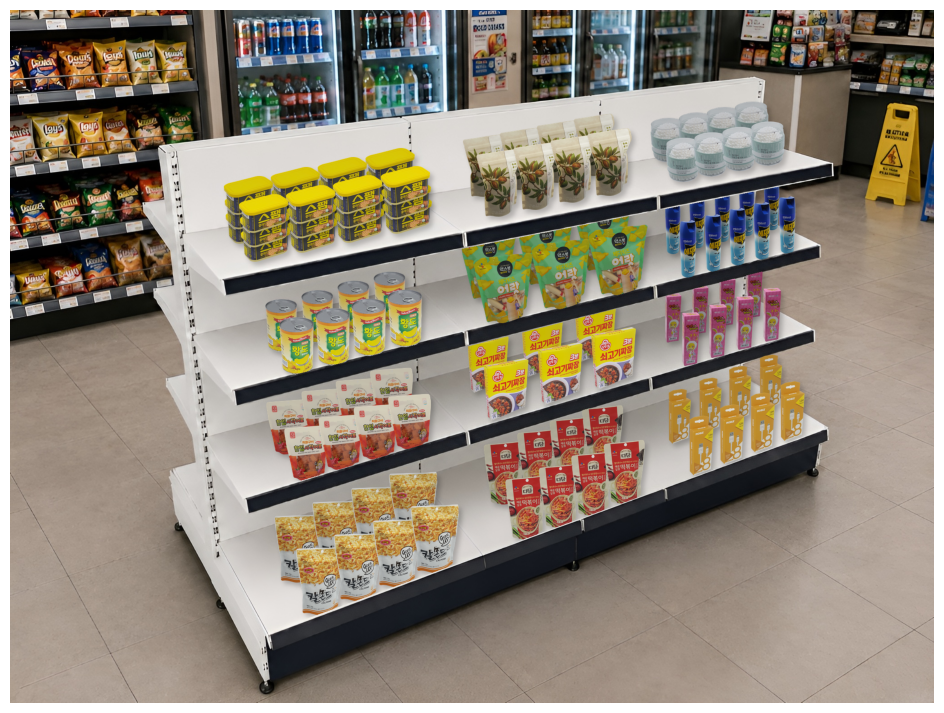

In [ ]:
# 7. 샘플 이미지 생성
sample_result = synthesize_one_side_shelf_sample(
    output_stem="side_shelf_sample_001",
    use_occluder=True,
)

print("이미지 저장:", sample_result["image_path"])
print("JSON 저장:", sample_result["json_path"])
print("YOLO 저장:", sample_result["yolo_path"])
print("객체 수:", len(sample_result["objects"]))

img = Image.open(sample_result["image_path"])

plt.figure(figsize=(16, 9))
plt.imshow(img)
plt.axis("off")
plt.show()